In [168]:
import numpy as np
import pandas as pd
import scanpy as sc
from tqdm.notebook import tqdm

import plotnine as p9

import liana as li
import decoupler as dc
# import omnipath as op

# Отображать все столбцы без ограничений
pd.set_option("display.max_columns", None)


In [62]:
import matplotlib.pyplot as plt

### steady-state LRI

In [7]:
adata = sc.read_h5ad("./data/adata_all_harm_ribo.h5ad")

sp_scores = pd.read_csv(
    "./data/sen_paper/sp_2nd_scores_is_sen_labels.csv",
    index_col=0,
)
adata.obs.drop(columns=["sp_score_sigs"], inplace=True, errors="ignore")
adata.obs = adata.obs.join(sp_scores, how="left")
adata = adata[adata.obs["is_sen_GMMk2_median_ct"].notna()].copy()

adata.obs["sen_group"] = pd.NA

# --- 2. Sc (сенесцентные по GMM) ---
mask_sc = adata.obs["is_sen_GMMk2_median_ct"] == True
adata.obs.loc[mask_sc, "sen_group"] = "Sc"

# NSc как все остальные:
adata.obs.loc[~mask_sc, "sen_group"] = "NSc"

adata = adata[adata.obs["sen_group"].notna()].copy()

In [8]:
adata.raw = adata.copy()

In [10]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

In [5]:
li.mt.show_methods().iloc[:, :3]

,Method Name,Magnitude Score,Specificity Score
0,CellPhoneDB,lr_means,cellphone_pvals
0,Connectome,expr_prod,scaled_weight
0,log2FC,None,lr_logfc
0,NATMI,expr_prod,spec_weight
0,SingleCellSignalR,lrscore,None
0,Rank_Aggregate,magnitude_rank,specificity_rank
0,Geometric Mean,lr_gmeans,gmean_pvals
0,scSeqComm,inter_score,None
0,CellChat,lr_probs,cellchat_pvals


In [ ]:
adata.obs["ct_state"] = (
    adata.obs.cell_type_final.astype(str) + "_" + adata.obs.sen_group
)
# фильтр по числу доноров в кл типе и числу клеток от донора делать не нужно, оно случилось где-то ранее

In [16]:
adata

AnnData object with n_obs × n_vars = 876940 × 43087
    obs: 'GSE_id', 'GSM_id', 'Age', 'Tissue_global', 'cell_type_final', 'Age_bin', 'sp_score_sigs_dw', 'centered_median', 'is_sen_GMMk2_median_ct', 'sen_group', 'ct_state'
    uns: 'Tissue_global_colors', 'log1p'
    obsm: 'X_scANVI', 'X_scVI', 'X_umap', '_scvi_extra_categorical_covs'

In [22]:
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
# Из библиотеки anndata тоже можно заглушить:
from anndata import ImplicitModificationWarning

warnings.filterwarnings("ignore", category=ImplicitModificationWarning)

In [24]:
t_dataframes = []
for t in tqdm(set(adata.obs.Tissue_global)):
    adata_t = adata[adata.obs.Tissue_global == t].copy()

    # Генерим pairs_df - указывает, какие именно пары клеток исследовать
    unique_states = adata_t.obs["ct_state"].unique()
    # Собираем пары по логике: если текущий элемент оканчивается на _Sc,
    # то он становится source, а все ОСТАЛЬНЫЕ уникальные элементы — это target
    pairs = []
    for state in unique_states:
        if state.endswith("_Sc"):
            # Мишенями становятся все клетки из списка, кроме текущего источника
            targets = [t for t in unique_states if t != state]
            for target in targets:
                pairs.append({"source": state, "target": target})
    pairs_df = pd.DataFrame(pairs, columns=["source", "target"])

    lri_df = li.mt.rank_aggregate(
        adata_t,
        groupby="ct_state",
        groupby_pairs=pairs_df,
        use_raw=False,
        n_jobs=10,
        # n_perms=500,
        #  resourse=[l, r] df
        resource_name="consensus",
        expr_prop=0.05,
        return_all_lrs=True,
        verbose=True,
        inplace=False,  # returns dataframe
    )
    lri_df["Tissue"] = t
    lri_df.to_csv(
        f"./data/sen_paper/3.2_liana_full_LRI/{t}.csv"
    )
    t_dataframes.append(lri_df)


In [30]:
lri_df

,source,target,ligand_complex,receptor_complex,lr_means,cellphone_pvals,expr_prod,scaled_weight,lr_logfc,spec_weight,lrscore,specificity_rank,magnitude_rank,Tissue
360146,Fibroblast_Sc,Atrial Cardiomyocyte_Sc,DCN,ERBB4,2.371503,0.0,5.617006,1.733366,1.746518,0.161510,0.962944,7.413411e-07,3.290839e-11,Heart_Nuclei
356022,Fibroblast_Sc,Atrial Cardiomyocyte_NSc,DCN,ERBB4,2.351478,0.0,5.518671,1.709309,2.146418,0.157882,0.962628,8.120254e-07,1.316334e-10,Heart_Nuclei
452140,Macrophage_Sc,CD4T_NSc,MRC1,PTPRC,2.326455,0.0,5.348627,3.432027,2.926708,0.058371,0.962061,2.026725e-06,2.961748e-10,Heart_Nuclei
456264,Macrophage_Sc,CD4T_Sc,MRC1,PTPRC,2.316000,0.0,5.305259,3.415152,2.905670,0.058108,0.961912,2.162228e-06,5.265323e-10,Heart_Nuclei
509876,Macrophage_Sc,NK_Sc,MRC1,PTPRC,2.297706,0.0,5.229382,3.385629,2.797274,0.057511,0.961647,2.505314e-06,8.227057e-10,Heart_Nuclei
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19,Adipocyte_Sc,Adipocyte_NSc,ADAM10,TSPAN10,0.065585,1.0,0.004300,-0.730689,-2.014861,0.000071,0.418267,1.000000e+00,1.000000e+00,Heart_Nuclei
18,Adipocyte_Sc,Adipocyte_NSc,ADAM10,TREM2,0.065585,1.0,0.004300,-0.730689,-2.014861,0.000071,0.418267,1.000000e+00,1.000000e+00,Heart_Nuclei
952642,Neural cell_Sc,Neural cell_NSc,ZP3,EGFR,0.065585,1.0,0.004300,-0.730689,-2.014861,0.000071,0.418267,1.000000e+00,1.000000e+00,Heart_Nuclei
952643,Neural cell_Sc,Neural cell_NSc,ZP3,MERTK,0.065585,1.0,0.004300,-0.730689,-2.014861,0.000071,0.418267,1.000000e+00,1.000000e+00,Heart_Nuclei


#### filt LRIs

In [ ]:
degs_df = pd.read_csv(
    "./data/sen_paper/2_pbDEGs_edgeR_NScFull.csv",
    index_col="gene_name",
)
degs_df.head(2)

,Unnamed: 0,logFC,logCPM,F,PValue,FDR,Tissue,cell_type
gene_name,,,,,,,,
MCOLN2,0,5.847347,6.462189,273.824358,2.122105e-17,7.628968e-14,Colon,B cell
NIBAN1,1,1.947866,6.438930,137.127296,3.316325e-13,5.961095e-10,Colon,B cell


In [36]:
lri_df = pd.concat(t_dataframes, ignore_index=True)
print(lri_df.shape)
lri_filt = lri_df[(lri_df.specificity_rank < 1) & (lri_df.magnitude_rank < 1)]
print(lri_filt.shape)

(4750935, 14)
(534583, 14)


In [ ]:
# только значимые DEGs
degs_sig = degs_df.reset_index().query("FDR < 0.05 and logFC > 0").copy()

# Разбираем source/target
lri_filt[["source_ct", "source_state"]] = lri_filt["source"].str.rsplit(
    "_", n=1, expand=True
)
lri_filt[["target_ct", "target_state"]] = lri_filt["target"].str.rsplit(
    "_", n=1, expand=True
)

# Оставляем только Sc sender - для подстраховки
lri = lri_filt.query("source_state == 'Sc'").copy()

/tmp/ipykernel_64037/395521304.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/tmp/ipykernel_64037/395521304.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


In [ ]:
from scipy import sparse

# 4. Genes whose expression will be calculated
needed_genes = sorted(set(lri["ligand_complex"]) | set(lri["receptor_complex"]))
print(f"{len(needed_genes)} genes required.")

# 5. Restrict AnnData to these genes
adata_sub = adata[:, adata.var_names.isin(needed_genes)].copy()
gene_names = adata_sub.var_names.to_numpy()

# 6. Calculate mean expression and % positive
expr_tables = []

groups = adata_sub.obs[["Tissue_global", "ct_state"]].drop_duplicates()

for t, ct in groups.itertuples(index=False):
    mask = (adata_sub.obs["Tissue_global"] == t) & (adata_sub.obs["ct_state"] == ct)
    X = adata_sub[mask].X

    if sparse.issparse(X):
        mean = np.asarray(X.mean(axis=0)).ravel()
        pct = np.asarray((X > 0).mean(axis=0)).ravel()
    else:
        mean = X.mean(axis=0)
        pct = (X > 0).mean(axis=0)

    expr_tables.append(
        pd.DataFrame(
            {"Tissue": t, "ct_state": ct, "gene": gene_names, "mean": mean, "pct": pct}
        )
    )

expr_df = pd.concat(expr_tables, ignore_index=True)

# 7. Merge ligand statistics
lig_expr = expr_df.rename(
    columns={
        "ct_state": "source",
        "gene": "ligand_complex",
        "mean": "ligand_mean",
        "pct": "ligand_pct",
    }
)
lri = lri.merge(lig_expr, on=["Tissue", "source", "ligand_complex"], how="left")

# 8. Merge receptor statistics
rec_expr = expr_df.rename(
    columns={
        "ct_state": "target",
        "gene": "receptor_complex",
        "mean": "receptor_mean",
        "pct": "receptor_pct",
    }
)
lri = lri.merge(rec_expr, on=["Tissue", "target", "receptor_complex"], how="left")

1538 genes required.


(534583, 22)
(287699, 22)
(246884, 22)


In [ ]:
lri["rank_within_tissue"] = lri.groupby("Tissue")["magnitude_rank"].rank(method="first")

lri["percentile"] = lri.groupby("Tissue")["magnitude_rank"].rank(pct=True)

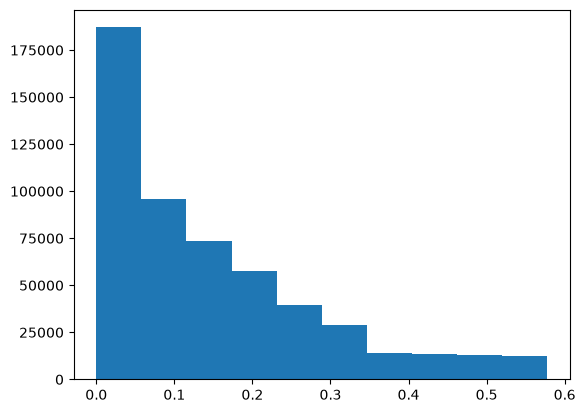

In [80]:
plt.hist(lri["magnitude_rank"])
plt.show()

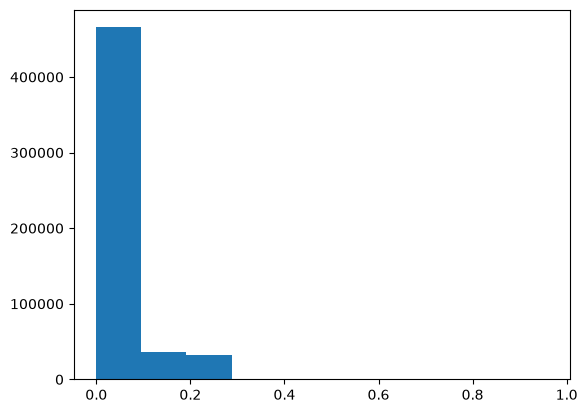

In [81]:
plt.hist(lri["specificity_rank"])
plt.show()

In [83]:
# 9. Final tables
lri_sc = lri.query("target_state == 'Sc'").copy()
lri_nsc = lri.query("target_state == 'NSc'").copy()

print(lri.shape)
print(lri_sc.shape)
print(lri_nsc.shape)

(534583, 24)
(287699, 24)
(246884, 24)


In [ ]:
lri_nsc = lri_nsc.merge(
    degs_sig[["gene_name", "Tissue", "cell_type", "logFC", "FDR"]],
    left_on=["Tissue", "source_ct", "ligand_complex"],
    right_on=["Tissue", "cell_type", "gene_name"],
    how="inner",
)

In [147]:
lri_nsc_filt = lri_nsc.loc[
    (lri_nsc["ligand_pct"] >= 0.2)
    & (lri_nsc["receptor_pct"] >= 0.05)
    & (lri_nsc["magnitude_rank"] < 0.25)
].copy()

print(f"Remaining interactions: {len(lri_nsc_filt):,}")

Remaining interactions: 13,185


#### final viz

In [294]:
output_dir = './data/sen_paper/3.2_LRI_chord_plots'

In [148]:
gene_to_group = {
    gene: group_name for group_name, genes in sasp_groups.items() for gene in genes
}

lri_nsc_filt["l_sasp_group"] = (
    lri_nsc_filt["ligand_complex"].map(gene_to_group).fillna("Other")
)

In [164]:
lri_nsc_filt.loc[:, "target_ct_cat"] = lri_nsc_filt["target_ct"].map(
    cell_type_to_category
)
lri_nsc_filt.loc[:, "source_ct_cat"] = lri_nsc_filt["source_ct"].map(
    cell_type_to_category
)

# Задание строгого порядка категорий (критично для seaborn/matplotlib)
# 1. Создаем правильный тип категории
cat_type = pd.CategoricalDtype(categories=category_order, ordered=True)

# 2. Применяем его сразу к двум столбцам
lri_nsc_filt[["target_ct_cat", "source_ct_cat"]] = lri_nsc_filt[["target_ct_cat", "source_ct_cat"]].astype(cat_type)


In [166]:
lri_nsc_filt.loc[
    lri_nsc_filt["Tissue"].isin(["Heart_Cell", "Heart_Nuclei"]), "Tissue"
] = "Heart"

lri_nsc_filt["target_ct"] = lri_nsc_filt["target_ct"].replace(unif_cts)
lri_nsc_filt["source_ct"] = lri_nsc_filt["source_ct"].replace(unif_cts)

In [189]:
lri_nsc_filt

,source,target,ligand_complex,receptor_complex,lr_means,cellphone_pvals,expr_prod,scaled_weight,lr_logfc,spec_weight,lrscore,specificity_rank,magnitude_rank,Tissue,source_ct,source_state,target_ct,target_state,ligand_mean,ligand_pct,receptor_mean,receptor_pct,rank_within_tissue,percentile,gene_name,cell_type,logFC,FDR,l_sasp_group,target_ct_cat,source_ct_cat
0,Endothelial cell_Sc,Mural cell_NSc,TGM2,ITGB1,1.682194,0.000,2.711483,0.503718,0.628437,0.327612,0.939462,0.000330,0.000041,Heart,Endothelial cells,Sc,Mural cells,NSc,1.338254,0.712691,2.026134,0.789784,25.0,0.011510,TGM2,Endothelial cell,0.841682,3.463613e-05,ECM and remodeling,Mesenchymal & Stromal,Endothelial
2,Endothelial cell_Sc,Mural cell_NSc,TIMP2,ITGB1,1.396797,0.000,1.554977,0.379014,0.458444,0.230440,0.921580,0.000884,0.000290,Heart,Endothelial cells,Sc,Mural cells,NSc,0.767460,0.473755,2.026134,0.789784,56.0,0.025783,TIMP2,Endothelial cell,0.285639,3.072202e-02,ECM and remodeling,Mesenchymal & Stromal,Endothelial
3,Endothelial cell_Sc,Endothelial cell_NSc,TGM2,ITGB1,1.361463,0.000,1.853042,0.225250,0.173438,0.223892,0.927688,0.000942,0.000352,Heart,Endothelial cells,Sc,Endothelial cells,NSc,1.338254,0.712691,1.384671,0.570533,61.0,0.028085,TGM2,Endothelial cell,0.841682,3.463613e-05,ECM and remodeling,Endothelial,Endothelial
4,Endothelial cell_Sc,Mural cell_NSc,VEGFC,ITGB1,1.323800,0.000,1.259173,0.428956,0.588087,0.368860,0.913609,0.000194,0.000697,Heart,Endothelial cells,Sc,Mural cells,NSc,0.621466,0.374020,2.026134,0.789784,83.0,0.038214,VEGFC,Endothelial cell,0.416157,8.426532e-03,Growth / angiogenesis / development,Mesenchymal & Stromal,Endothelial
5,Endothelial cell_Sc,Mural cell_NSc,TIMP1,CD63,1.502164,0.000,1.166980,0.099438,-0.201598,0.071520,0.910560,0.003406,0.000981,Heart,Endothelial cells,Sc,Mural cells,NSc,0.458365,0.257146,2.545964,0.925144,98.0,0.045120,TIMP1,Endothelial cell,1.619135,4.600981e-07,ECM and remodeling,Mesenchymal & Stromal,Endothelial
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24930,Adipocyte_Sc,Monocyte_NSc,HLA-C,LILRA1,0.192963,0.524,0.031567,0.721642,-0.137984,0.015897,0.660797,0.001480,0.192227,Heart,Adipocytes,Sc,Monocytes / macrophages,NSc,0.268249,0.206198,0.117677,0.059005,79575.0,0.853150,HLA-C,Adipocyte,0.868127,9.644221e-03,Immune interface,Immune,Mesenchymal & Stromal
24935,Adipocyte_Sc,NK_NSc,HLA-C,CD8A,0.192341,0.569,0.031233,0.472170,-0.135573,0.005185,0.659606,0.001499,0.192672,Heart,Adipocytes,Sc,NK cells,NSc,0.268249,0.206198,0.116434,0.055172,79688.0,0.854367,HLA-C,Adipocyte,0.868127,9.644221e-03,Immune interface,Immune,Mesenchymal & Stromal
24947,Adipocyte_Sc,NK_NSc,HLA-C,KIR3DL1,0.191669,0.532,0.030873,1.289312,-0.120316,0.011943,0.658301,0.001483,0.193212,Heart,Adipocytes,Sc,NK cells,NSc,0.268249,0.206198,0.115090,0.053793,79832.0,0.855911,HLA-C,Adipocyte,0.868127,9.644221e-03,Immune interface,Immune,Mesenchymal & Stromal
25011,Neural cell_Sc,Macrophage_NSc,SPON1,LRP8,0.206889,0.001,0.029381,0.141750,-0.011210,0.006879,0.652708,0.000961,0.197373,Heart,Neural cells,Sc,Monocytes / macrophages,NSc,0.322745,0.207207,0.091034,0.052931,80812.0,0.866418,SPON1,Neural cell,1.565591,3.663189e-06,ECM and remodeling,Immune,Tissue-Specific


In [170]:
lri_nsc_filt = lri_nsc_filt[lri_nsc_filt.l_sasp_group != 'Other']

In [297]:
'''viz - pie plot'''

In [354]:
'''viz - chord diagrams'''

In [ ]:
'''viz - full dotplot'''

In [298]:
lri.to_csv('./data/sen_paper/3.2_all_steady_state_LRIs.csv')
lri_nsc_filt.to_csv('./data/sen_paper/3.2_Sc-NSc_filt_LRIs.csv')


## !! long dicts

In [ ]:
sasp_groups = {
    "Pro-inflammatory SASP": [
        "AIMP1",
        "C1QA",
        "C1QB",
        "C1QTNF1",
        "C3",
        "CCL15",
        "CCL2",
        "CCL5",
        "CCL8",
        "CD40LG",
        "CD70",
        "CFH",
        "CKLF",
        "CSF1",
        "CSF3",
        "CX3CL1",
        "CXCL1",
        "CXCL12",
        "CXCL16",
        "CXCL2",
        "CXCL3",
        "CXCL8",
        "GDF15",
        "GRN",
        "GZMB",
        "IL18",
        "IL32",
        "IL6",
        "LGALS1",
        "LGALS3",
        "LGALS8",
        "LGALS9",
        "LTB",
        "LTF",
        "MIF",
        "PTGS2",
        "RARRES2",
        "S100A4",
        "S100A8",
        "S100A9",
        "SAA1",
        "TNFSF10",
        "TNFSF12",
        "TNFSF13",
        "TNFSF9",
        "TPSB2",
        "XCL1",
    ],
    "ECM and remodeling": [
        "A2M",
        "ADAM9",
        "ADAM10",
        "ADAM12",
        "ADAM15",
        "ADAM17",
        "ADAM28",
        "ADAMTS3",
        "APOA1",
        "APOA4",
        "APOB",
        "APOC1",
        "APOC3",
        "APOD",
        "APOE",
        "BGN",
        "COL14A1",
        "COL18A1",
        "COL1A1",
        "COL1A2",
        "COL3A1",
        "COL4A1",
        "COL4A2",
        "COL4A3",
        "COL4A4",
        "COL5A1",
        "COL5A3",
        "COL6A1",
        "COL6A2",
        "COL6A3",
        "CTHRC1",
        "DCN",
        "ECM1",
        "EDIL3",
        "EFEMP1",
        "F13A1",
        "FBLN1",
        "FBLN2",
        "FBN1",
        "FN1",
        "GAS6",
        "HAS2",
        "HSPG2",
        "LAMA2",
        "LAMA3",
        "LAMA4",
        "LAMB1",
        "LAMB3",
        "LAMC1",
        "LAMC2",
        "LGALS3BP",
        "LPL",
        "LTBP1",
        "LTBP3",
        "LUM",
        "MFAP5",
        "MFGE8",
        "NID1",
        "PLA2G2A",
        "PLAT",
        "PLAU",
        "PLTP",
        "PRG4",
        "PROS1",
        "PRSS3",
        "RARRES1",
        "SCGB1A1",
        "SCGB3A1",
        "SCGB3A2",
        "SERPINA1",
        "SERPINE1",
        "SERPINE2",
        "SERPINF1",
        "SERPING1",
        "SFTPA1",
        "SFTPA2",
        "SLPI",
        "SPARC",
        "SPINK1",
        "SPINT1",
        "SPON1",
        "SPON2",
        "TFPI",
        "TGM2",
        "THBS1",
        "THBS2",
        "TIMP1",
        "TIMP2",
        "TIMP3",
        "TNC",
        "VCAN",
    ],
    "Growth / angiogenesis / development": [
        "ACE",
        "AGT",
        "AGTRAP",
        "ANGPT2",
        "ANGPTL1",
        "ANGPTL4",
        "AREG",
        "AZGP1",
        "BMP2",
        "CCN1",
        "CCN2",
        "CEACAM1",
        "CEACAM6",
        "CLCF1",
        "CNTN3",
        "CNTN4",
        "EDA",
        "EDN1",
        "EFNA1",
        "EFNA5",
        "EFNB2",
        "FAM3B",
        "FAM3C",
        "FGF10",
        "FGF12",
        "FGF13",
        "FGF14",
        "FGF2",
        "FGF7",
        "FGFR4",
        "FSTL1",
        "GPC3",
        "GUCA2A",
        "GUCA2B",
        "HBEGF",
        "HGF",
        "IGFBP4",
        "IGFBP7",
        "INHBA",
        "KITLG",
        "LRIG1",
        "MDK",
        "NELL2",
        "NGF",
        "NLGN1",
        "NPPA",
        "NTF3",
        "NTN4",
        "PDAP1",
        "PDGFA",
        "PDGFC",
        "PGF",
        "RGMB",
        "SEMA3E",
        "SEMA4A",
        "SEMA4B",
        "SEMA4C",
        "SEMA4G",
        "SEMA5A",
        "SEMA6A",
        "SEMA6B",
        "SHANK2",
        "SLIT2",
        "SLIT3",
        "TFF3",
        "TG",
        "TGFA",
        "TGFB1",
        "TGFB3",
        "VEGFA",
        "VEGFC",
        "ZG16B",
    ],
    "Immune interface": [
        "ALCAM",
        "B2M",
        "BSG",
        "BTLA",
        "CADM1",
        "CD14",
        "CD22",
        "CD24",
        "CD274",
        "CD38",
        "CD47",
        "CD48",
        "CD52",
        "CD55",
        "CD58",
        "CD59",
        "CD86",
        "CD96",
        "CD99",
        "CDH1",
        "CLEC2B",
        "CLEC2D",
        "DSC2",
        "FCER2",
        "HHLA2",
        "HLA-A",
        "HLA-B",
        "HLA-C",
        "HLA-DMA",
        "HLA-DMB",
        "HLA-DOB",
        "HLA-DPA1",
        "HLA-DPB1",
        "HLA-DQA1",
        "HLA-DQB1",
        "HLA-DRA",
        "HLA-DRB1",
        "HLA-DRB5",
        "HLA-E",
        "HLA-F",
        "ICAM1",
        "ICAM3",
        "ICAM4",
        "ITGB2",
        "JAG1",
        "MRC1",
        "NCR3LG1",
        "NECTIN1",
        "NECTIN2",
        "NECTIN3",
        "PDCD1LG2",
        "PODXL2",
        "SECTM1",
        "SELE",
        "SELL",
    ],
    # "Non-ligand / not classifiable": [
    #     'ACTR2', 'ADA', 'AFDN', 'ANXA1', 'ANXA2', 'APP', 'ARF1', 'ARF6', 'ARPC5',
    #     'CALM1', 'CALM3', 'CALR', 'CGN', 'COPA', 'DNAJB11', 'ETV5', 'FABP5', 'FARP2',
    #     'GNAI2', 'GNAS', 'GPI', 'GSTO1', 'GSTP1', 'HDC', 'HEBP1', 'HMGB1', 'HSPA1A',
    #     'HSPA4', 'HSPA8', 'ITGAV', 'ITGB3BP', 'LMAN1', 'LRPAP1', 'MAML2', 'MYL9',
    #     'NAMPT', 'NUCB2', 'P4HB', 'PAM', 'PKM', 'PSAP', 'PSEN1', 'PTDSS1', 'PTPN6',
    #     'RIMS2', 'RPS19', 'RTN4', 'S100A10', 'SERTAD1', 'SLC6A8', 'SOCS2', 'SORBS1',
    #     'SPTAN1', 'ST6GAL1', 'TCN2', 'TCTN1', 'TGS1', 'TLN1', 'TXLNA', 'VASP', 'VCL',
    #     'VIM', 'VWF', 'WASF', 'YBX1'
    # ]
}
